In [1]:
import pandas as pd

df = pd.read_csv('Housing.csv')
print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


### Encoding

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['mainroad_encoded'] = encoder.fit_transform(df['mainroad'])
df['guestroom_encoded'] = encoder.fit_transform(df['guestroom'])
df['basement_encoded'] = encoder.fit_transform(df['basement'])
df['hotwaterheating'] = encoder.fit_transform(df['hotwaterheating'])
df['airconditioning_encoded'] = encoder.fit_transform(df['airconditioning'])
df['parking_encoded'] = encoder.fit_transform(df['parking'])
df['prefarea_encoded'] = encoder.fit_transform(df['prefarea'])
df['furnishingstatus_encoded'] = encoder.fit_transform(df['furnishingstatus'])

print(df.head())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

   hotwaterheating airconditioning  parking prefarea furnishingstatus  \
0                0             yes        2      yes        furnished   
1                0             yes        3       no        furnished   
2                0              no        2      yes   semi-furnished   
3                0             yes        3      yes        furnished   
4                0             yes        2       no        furnished   

   mainroad_encoded  guestroom_encoded  basement_encoded  \
0                 1       

In [10]:
from sklearn.model_selection import train_test_split

X = df[['area','bedrooms','bathrooms','stories','mainroad_encoded','guestroom_encoded','basement_encoded','airconditioning_encoded','parking_encoded','prefarea_encoded','furnishingstatus_encoded']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [12]:
print("Coefficients (Weights):", model.coef_)
print("Intercept (Bias):", model.intercept_)

Coefficients (Weights): [ 2.36337443e+02  7.96981641e+04  1.10966218e+06  4.17838171e+05
  3.55376271e+05  2.26650663e+05  4.05046645e+05  7.27313647e+05
  2.40331152e+05  6.12209904e+05 -2.17610244e+05]
Intercept (Bias): 311782.33015380055


In [15]:
predictions = model.predict(X_test)
print('Predicted Prices:', predictions)
print('Actual prices:', list(y_test))

Predicted Prices: [5290123.90788959 7254808.89453281 3091248.30541501 4542982.23381563
 3369649.71769024 3586720.57421616 5655324.41047674 6464183.00828209
 2796173.65035828 2716488.26761431 9616641.34868501 2848586.29275174
 3169947.45582325 3416297.81749767 3759677.42097827 5364874.79026358
 3026958.09213151 4802040.58530367 4444322.9663388  3554469.69452363
 5777984.98559084 5800367.10858779 2781230.12137625 4798691.77427091
 5291967.20636641 7595483.33481619 3280814.79835815 5301963.42781286
 8196478.36583933 3480905.77921473 6433563.51589226 3394075.10091887
 6751080.93183156 4197353.55761617 3624580.58214642 5798440.58482656
 4844364.74282343 4379982.6520901  3192924.63349038 4699624.40859718
 4582778.30004077 3504053.35727844 7235901.89905899 4084540.02713638
 3731722.77709071 4277325.44392251 6724658.19649059 4050616.42267053
 3821351.20987985 3513556.0689221  7336307.98533017 2868178.2723206
 4430728.36476812 4474483.88561677 3761384.22873735 2766119.13073309
 7527155.31064895

In [16]:
import numpy as np

predictions = predictions.astype(int)
print('Predicted Prices:', predictions)
print('Actual prices:', list(y_test))

Predicted Prices: [5290123 7254808 3091248 4542982 3369649 3586720 5655324 6464183 2796173
 2716488 9616641 2848586 3169947 3416297 3759677 5364874 3026958 4802040
 4444322 3554469 5777984 5800367 2781230 4798691 5291967 7595483 3280814
 5301963 8196478 3480905 6433563 3394075 6751080 4197353 3624580 5798440
 4844364 4379982 3192924 4699624 4582778 3504053 7235901 4084540 3731722
 4277325 6724658 4050616 3821351 3513556 7336307 2868178 4430728 4474483
 3761384 2766119 7527155 2983580 4238056 2816917 4883369 3675237 5106765
 4223428 4776012 4003272 7294315 3530430 6037973 6232760 4861475 5167135
 4579620 8009860 3520809 4830139 3972548 4613933 4819422 4235268 7782082
 4078900 6567841 5427836 2818144 6916295 2660277 3689676 8032599 7463388
 3293270 5935611 3642094 3811829 7738749 4759702 5153381 6459780 4986606
 5982587 3880376 6483032 3753741 6038265 5017413 4454063 7044687 6355963
 6482992]
Actual prices: [4060000, 6650000, 3710000, 6440000, 2800000, 4900000, 5250000, 4543000, 2450000,

In [17]:
from sklearn.metrics import r2_score

score = r2_score(y_test, predictions)
print('R2 Score:', score)

R2 Score: 0.6365502950643205


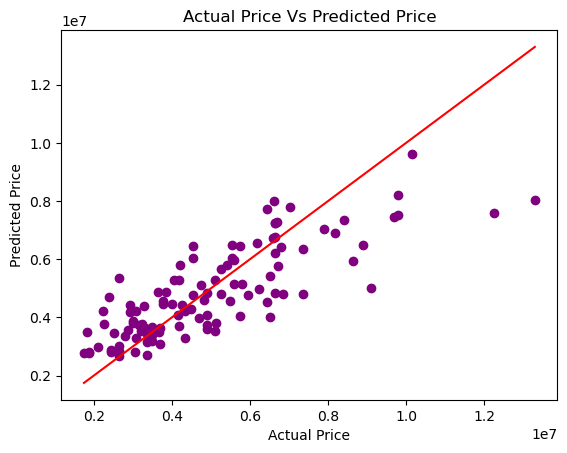

In [18]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions, color='purple')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual Price Vs Predicted Price')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.show()